# VASICEK MODEL FOR BOND PRICING

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

## Calibrating the Model

In [2]:
T = np.linspace(0.25, 10, 40)   # 3 months to 10 years

In [3]:
def yield_curve(T):
    return 0.02 + 0.015*(1 - np.exp(-0.5*T))

In [4]:
P_market = np.exp(-yield_curve(T) * T)

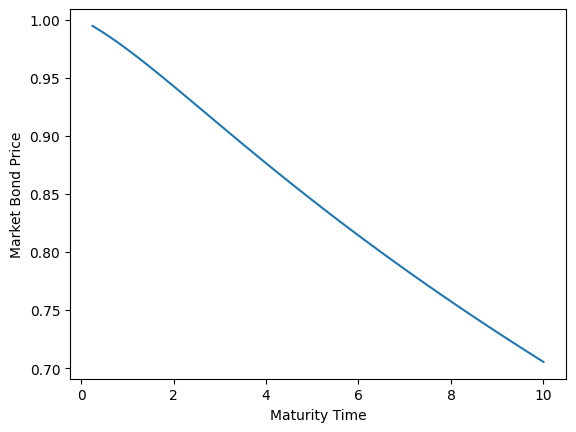

In [6]:
plt.plot(T, P_market)
plt.xlabel('Maturity Time')
plt.ylabel('Market Bond Price')
plt.show()

In [7]:
def vasicek_bond_price(T, alpha, mu, sigma, r0):
    B = (1 - np.exp(-alpha * T)) / alpha
    
    A = np.exp(
        (mu - sigma**2/(2*alpha**2)) * (B - T)
        - (sigma**2/(4*alpha)) * B**2
    )
    
    return A * np.exp(-B * r0)

Continuously compounded interest:

$\frac{dP}{P} = r(s)ds$

$ ln|P_T| - ln|P_0| = \int_0^T r(s)ds$

$ P(0) = e^{- \int_0^T r(s) ds}$

But if we define the average interest rate over the time period,

$\overline{r} = \frac{1}{T} \int_0^T r(s) ds$

then it is evaluated using

$-ln|P_0|/T = \overline{r}$

In [8]:
def model_yield(T, alpha, mu, sigma, r0):
    P = vasicek_bond_price(T, alpha, mu, sigma, r0)
    return -np.log(P) / T

In [9]:
def objective(params, T, y_market):
    alpha, mu, sigma, r0 = params
    y_model = model_yield(T, alpha, mu, sigma, r0)
    return np.mean((y_model - y_market)**2)

In [10]:
init = [0.5, 0.05, 0.05, 0.03]

bounds = [
    (1e-3, 2.0),   # alpha
    (0.0, 0.1),    # mu
    (1e-3, 0.3),   # sigma
    (0.0, 0.1)     # r0
]

In [11]:
from scipy.optimize import minimize

y_market = yield_curve(T)

res = minimize(objective, init, args=(T, y_market), bounds=bounds)

alpha_fit, mu_fit, sigma_fit, r0_fit = res.x

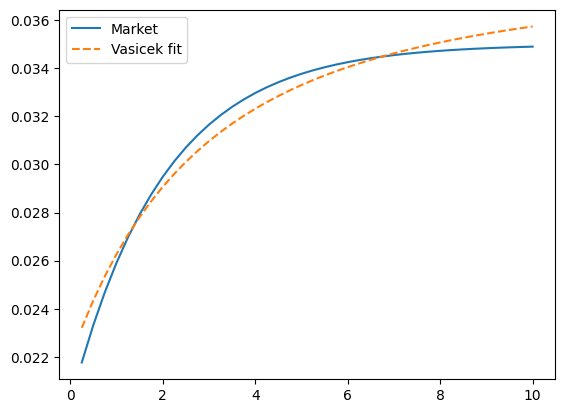

In [12]:
y_fit = model_yield(T, alpha_fit, mu_fit, sigma_fit, r0_fit)

plt.plot(T, y_market, label='Market')
plt.plot(T, y_fit, '--', label='Vasicek fit')
plt.legend()

## PDE Solver

In [13]:
T = 1 #maturity time

#params in vasicek model
alpha = 0.5

mu = 0.05

sig = 0.1

rmin = 0.

rmax = 0.35

## Load in Chebyshev Polynomials and Match to Terminal Condition

In [14]:
n = 50 #grid resolution

diff = np.loadtxt('diffmatrix100.txt')[0:n,0:n]

chebyshevs = []
for i in range(0, n):
    chebyshevs.append(scipy.special.chebyt(i))

In [15]:
# tau array

tau = np.linspace(0, T, int(T/10**-3 + 1))
dtau = tau[1:] - tau[0:-1]

# solution array

c = np.zeros((len(tau), n))

#match to terminal condition

#coefficient of T_0 matched to unity at tau = 0!
c[0,0] = 1.


In [16]:
# transform to two numerical coordinates

def xnum_to_r(xnum):
    return rmax + (xnum - 1.)*((rmax - rmin)/2) 

In [17]:
# functions to plot data

xplot = np.linspace(-1,1,101)

def calc_u(c,x):
    sum = 0.0
    for i in range(len(c)):
        sum = sum + c[i]*chebyshevs[i](x)
    return sum

def plot_frame(tau_index):

    #left part
  
    plt.plot(xnum_to_r(xplot), calc_u(c[tau_index,:], xplot), c='blue')
       
    plt.title('p(x) at '+r'$\tau=$ '+str(tau[tau_index]))
    plt.ylabel(r'$p$')
    plt.xlabel(r'$x$')
    plt.show()



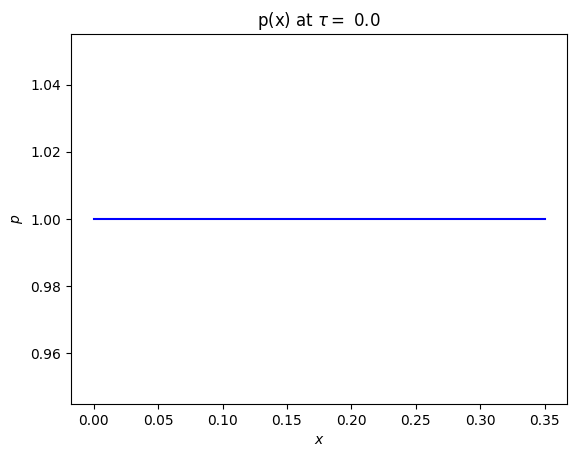

In [18]:
plot_frame(0)

## Method of Lines Solution with SDIRK

In [19]:
c1 = 1/4
c2 = 0.
c3 = 1/2
c4 = 1.
c5 = 1.

a11 = 1/4
a21 = -1/4
a22 = 1/4
a31 = 1/8
a32 = 1/8
a33 = 1/4
a41 = -3/2
a42 = 3/4
a43 = 3/2
a44 = 1/4
a51 = 0.
a52 = 1/6
a53 = 2/3
a54 = -1/12
a55 = 1/4

b1 = 0.
b2 = 1/6
b3 = 2/3
b4 = -1/12
b5 = 1/4

In [20]:
def calc_T_matrix(dim, xcol):
    T = np.zeros(dim)
    for i in range(0,dim):
        T[i] = chebyshevs[i](xcol)
    return T

#Gauss-Lobatto Nodes
xcol = np.cos(np.pi*np.linspace(1, n-2, int(n-2))/(n-1))

#collocation matrices
Tcol = np.zeros((len(xcol),n))
for i in range(0, len(xcol)):
    Tcol[i,:] = calc_T_matrix(n, xcol[i])
    
Tdiffcol = np.matmul(Tcol, diff)
Tdiff2col = np.matmul(np.matmul(Tcol, diff), diff)

In [21]:
def vasicek_analytical(tau, alpha, mu, sig, r):
    q  = (1 - np.exp(-alpha*tau))/alpha
    f = (q - tau)*(mu - sig**2/(2*alpha**2)) - sig**2*q**2/(4*alpha)

    return np.exp(f - q*r)

In [22]:
def calc_K(c, tau_inp, dtau_inp, K1, K2, K3, K4, key):

    dtau = dtau_inp

    if key == 1:
        tau = tau_inp + dtau*c1
    elif key == 2:
        tau = tau_inp + dtau*c2
    elif key == 3:
        tau = tau_inp + dtau*c3
    elif key == 4:
        tau = tau_inp + dtau*c4
    elif key == 5:
        tau = tau_inp + dtau*c5
    

    L = np.zeros((n, n))
    R = np.zeros((n, n))
    J = np.zeros(n)
    
    #prepare the matrices
    
###################################################################################################
  
    #PDE

    rcol = xnum_to_r(xcol)
    L[0:len(xcol),:] = Tcol 
    R[0:len(xcol),:] = (1/2)*sig**2*(2/(rmax - rmin))**2*Tdiff2col + (alpha*(mu - rcol)*(2/(rmax - rmin))*Tdiffcol.T).T + ((-rcol)*Tcol.T).T
    
    row_count = len(xcol)    
        
#############################################################################################################################################
    
    #boundary conditions

    #left cell
    R[row_count, :] = calc_T_matrix(n, -1.)
    J[row_count] =  vasicek_analytical(tau, alpha, mu, sig, rmin)

    row_count = row_count + 1

    #right cell
    R[row_count, :] = calc_T_matrix(n, +1.)
    J[row_count] = vasicek_analytical(tau, alpha, mu, sig, rmax)

    row_count = row_count + 1
    
####################################################################################################################################################
    
    if key == 1:
        Lbar = L - R*(dtau)*(a11)
        Rbar = np.matmul(R, c) - J
        K1 = np.linalg.solve(Lbar,Rbar)
        return K1
    elif key == 2:
        Lbar = L - R*(dtau)*(a22)
        Rbar = np.matmul(R, c + dtau*K1*a21) - J
        K2 = np.linalg.solve(Lbar,Rbar)
        return K2
    elif key == 3:
        Lbar = L - R*(dtau)*(a33)
        Rbar = np.matmul(R, c + dtau*K1*a31 + dtau*K2*a32) - J
        K3 = np.linalg.solve(Lbar,Rbar)
        return K3
    elif key == 4:
        Lbar = L - R*(dtau)*(a44)
        Rbar = np.matmul(R, c + dtau*K1*a41 + dtau*K2*a42 + dtau*K3*a43) - J
        K4 = np.linalg.solve(Lbar,Rbar)
        return K4
    elif key == 5:
        Lbar = L - R*(dtau)*(a55)
        Rbar = np.matmul(R, c + dtau*K1*a51 + dtau*K2*a52 + dtau*K3*a53 + dtau*K4*a54) - J
        K5 = np.linalg.solve(Lbar,Rbar)
        return K5
    

In [23]:
#Calculate Data for all Times

for i in range(0, len(tau)-1):
    K1 = calc_K(c[i,:],tau[i], dtau[i], None, None, None, None, 1)
    K2 = calc_K(c[i,:],tau[i], dtau[i], K1, None, None, None, 2)
    K3 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, None, None, 3)
    K4 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, None, 4)
    K5 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , 5)

    c[i+1,:] = c[i,:] + dtau[i]*(b1*K1 + b2*K2 +b3*K3 + b4*K4 + b5*K5)
    
    if i%100==0:
        print(i)
        print('The time is: '+str(tau[i]))
        print('The average of the Chebychev coefficients is: '+str(np.mean(np.abs(c[i,:]))))


0
The time is: 0.0
The average of the Chebychev coefficients is: 0.02
100
The time is: 0.1
The average of the Chebychev coefficients is: 0.019997573412565653
200
The time is: 0.2
The average of the Chebychev coefficients is: 0.019990574955180685
300
The time is: 0.3
The average of the Chebychev coefficients is: 0.01997940013925619
400
The time is: 0.4
The average of the Chebychev coefficients is: 0.01996441138348976
500
The time is: 0.5
The average of the Chebychev coefficients is: 0.019945940616858556
600
The time is: 0.6
The average of the Chebychev coefficients is: 0.01992429171503526
700
The time is: 0.7000000000000001
The average of the Chebychev coefficients is: 0.01989974277468427
800
The time is: 0.8
The average of the Chebychev coefficients is: 0.019872548229572587
900
The time is: 0.9
The average of the Chebychev coefficients is: 0.019842940813983613


## Analysis

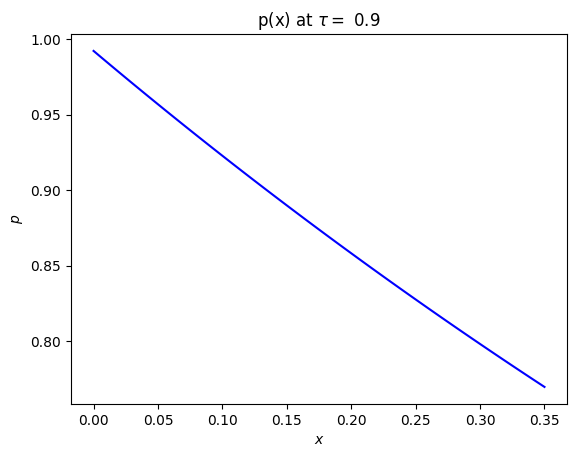

In [24]:
plot_frame(900)

In [25]:
def plot_coeff(tau_index):
    plt.plot(np.log10(np.abs(c[tau_index, :])), c='red')
    plt.xlabel(r'$k$')
    plt.ylabel(r'$log_{10}|c_k|$')
    plt.legend()
    plt.show()

C:\Users\ar3n23\AppData\Local\Temp\ipykernel_6096\213752776.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


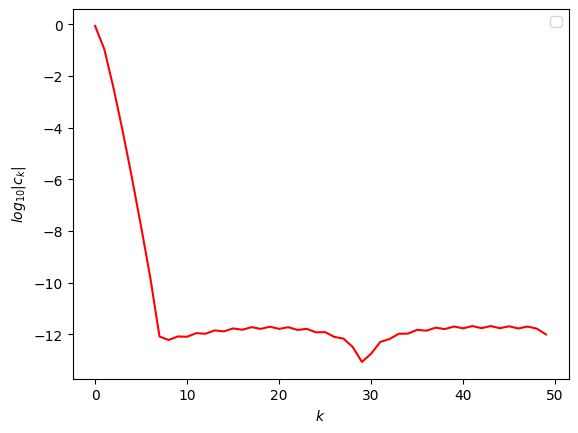

In [26]:
plot_coeff(901)

## Heatmap of Errors with Fixed N and Timestep

In [27]:
def r_to_xnum(r):
    return 1 + 2*(r - rmax)/(rmax - rmin)


In [28]:
# heatmap of errors

#pass in solution array

def vasicek_heatmap(c):

    numerical_solution = np.zeros((len(tau), len(xplot)))
    analytical_solution = np.zeros((len(tau), len(xplot)))

    for i in range(0, len(tau)):
            numerical_solution[i,:] = calc_u(c[i,:], xplot)
            analytical_solution[i,:] = vasicek_analytical(tau[i], alpha, mu, sig, xnum_to_r(xplot))

    errors = np.abs(numerical_solution - analytical_solution)

    return numerical_solution, errors

In [29]:
num_vasicek, errors_vasicek = vasicek_heatmap(c)

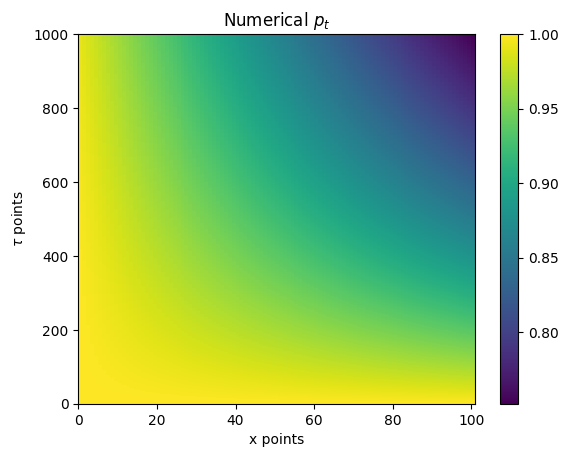

In [30]:
plt.pcolormesh(num_vasicek)
plt.title('Numerical '+r'$p_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.colorbar()

C:\Users\ar3n23\AppData\Local\Temp\ipykernel_6096\1758688211.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(np.log10(errors_vasicek))


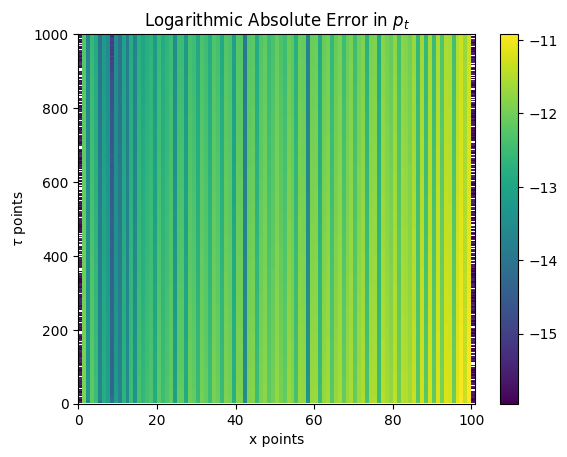

In [31]:
plt.pcolormesh(np.log10(errors_vasicek))
plt.title('Logarithmic Absolute Error in '+r'$p_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.colorbar()